In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega os dois CSVs
df_attack = pd.read_csv('data/raw/attack_samples_5sec.csv')
df_benign = pd.read_csv('data/raw/benign_samples_5sec.csv')

print("=== ATAQUES ===")
print(f"Linhas: {df_attack.shape[0]} | Colunas: {df_attack.shape[1]}")

print("\n=== BENIGNOS ===")
print(f"Linhas: {df_benign.shape[0]} | Colunas: {df_benign.shape[1]}")

=== ATAQUES ===
Linhas: 17695 | Colunas: 94

=== BENIGNOS ===
Linhas: 27360 | Colunas: 94


In [7]:
print("=== PRIMEIRAS LINHAS DOS ATAQUES ===")
print(df_attack.head())

print("\n=== PRIMEIRAS LINHAS DOS BENIGNOS ===")
print(df_benign.head())

=== PRIMEIRAS LINHAS DOS ATAQUES ===
  device_name         device_mac                           label_full  label1  \
0       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
1       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
2       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
3       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
4       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   

  label2             label3                  label4  \
0   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
1   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
2   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
3   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
4   ddos  syn-flood-port-80  ddos_syn-flood-port-80   

                                           timestamp  \
0  2025-01-23T15:31:10.709000Z_2025-01-23T15:31:1...   
1  2025-01-23T15:31:15.709000Z_20

In [8]:
print("=== INFORMAÇÕES DOS ATAQUES ===")
print(df_attack.info())

print("\n=== VALORES NULOS NOS ATAQUES ===")
print(df_attack.isnull().sum())

print("\n=== VALORES NULOS NOS BENIGNOS ===")
print(df_benign.isnull().sum())

=== INFORMAÇÕES DOS ATAQUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17695 entries, 0 to 17694
Data columns (total 94 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   device_name                           17695 non-null  object 
 1   device_mac                            17695 non-null  object 
 2   label_full                            17695 non-null  object 
 3   label1                                17695 non-null  object 
 4   label2                                17695 non-null  object 
 5   label3                                17695 non-null  object 
 6   label4                                17695 non-null  object 
 7   timestamp                             17695 non-null  object 
 8   timestamp_start                       17695 non-null  object 
 9   timestamp_end                         17695 non-null  object 
 10  log_data-ranges_avg                   17695 non-nu

=== DISTRIBUIÇÃO DE CLASSES ===
label
benign    27360
attack    17695
Name: count, dtype: int64


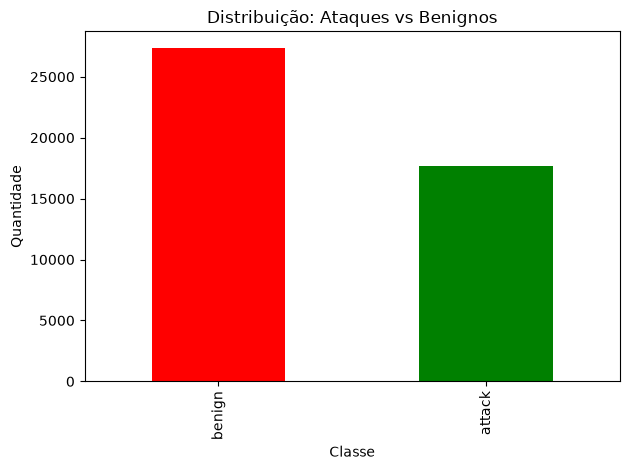

In [9]:
# Adiciona coluna de label em cada dataframe
df_attack['label'] = 'attack'
df_benign['label'] = 'benign'

# Junta os dois em um único dataframe
df = pd.concat([df_attack, df_benign], ignore_index=True)

# Mostra quantos registros tem de cada classe
print("=== DISTRIBUIÇÃO DE CLASSES ===")
print(df['label'].value_counts())

# Gráfico de barras
df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribuição: Ataques vs Benignos')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

In [10]:
print("=== ESTATÍSTICAS DOS DADOS NUMÉRICOS ===")

# Seleciona apenas colunas numéricas
df_numeric = df.select_dtypes(include=[np.number])

print(f"Total de colunas numéricas: {df_numeric.shape[1]}")
print("\n")
print(df_numeric.describe().round(2))

=== ESTATÍSTICAS DOS DADOS NUMÉRICOS ===
Total de colunas numéricas: 71


       log_data-ranges_avg  log_data-ranges_max  log_data-ranges_min  \
count             45055.00             45055.00             45055.00   
mean                 62.65                64.74                59.76   
std                 220.43               223.23               214.90   
min                   0.00                 0.00                -0.94   
25%                   0.00                 0.00                 0.00   
50%                   0.00                 0.00                 0.00   
75%                   0.00                 0.00                 0.00   
max                2000.00              2000.00              2000.00   

       log_data-ranges_std_deviation  log_data-types_count  \
count                       45055.00              45055.00   
mean                            1.58                  0.34   
std                            16.81                  0.60   
min                          